In [5]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [6]:
df = pd.read_csv("Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [7]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]
Scaler = StandardScaler()
X_scaled = Scaler.fit_transform(X)

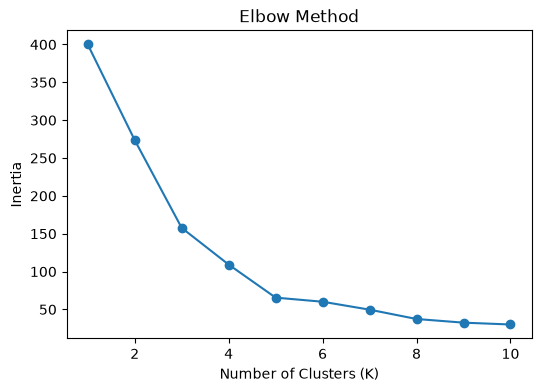

In [8]:
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
plt.figure(figsize=(6,4))
plt.plot(range(1,11), inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [9]:
kmeans = KMeans(n_clusters=5, random_state=42)

kmeans_labels = kmeans.fit_predict(X_scaled)
score = silhouette_score(X_scaled, kmeans_labels)

print("Silhouette Score:", score)

Silhouette Score: 0.5546571631111091


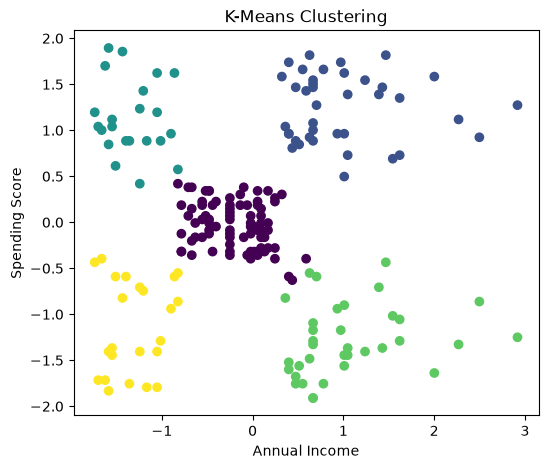

In [10]:
plt.figure(figsize=(6,5))

plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=kmeans_labels,
    cmap='viridis'
)

plt.title("K-Means Clustering")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.show()

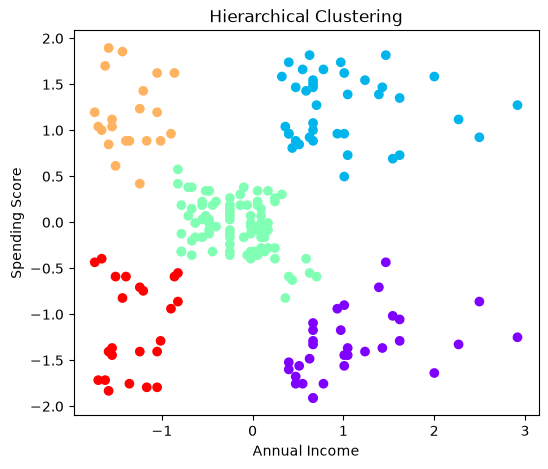

In [11]:
hc = AgglomerativeClustering(n_clusters=5)

hc_labels = hc.fit_predict(X_scaled)
plt.figure(figsize=(6,5))

plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=hc_labels,
    cmap='rainbow'
)

plt.title("Hierarchical Clustering")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.show()

Outliers: 8


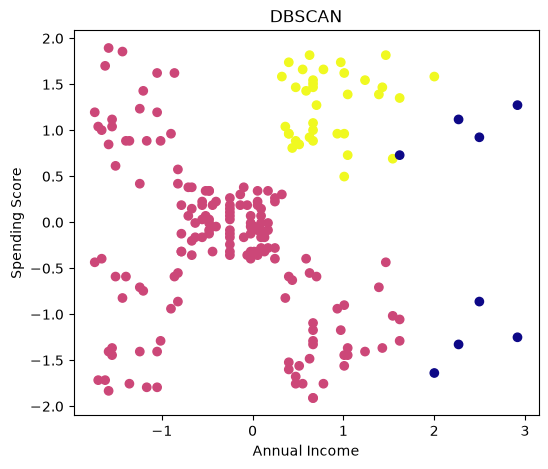

In [12]:
dbscan = DBSCAN(eps=0.5, min_samples=5)

dbscan_labels = dbscan.fit_predict(X_scaled)
print("Outliers:", sum(dbscan_labels == -1))
plt.figure(figsize=(6,5))

plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=dbscan_labels,
    cmap='plasma'
)

plt.title("DBSCAN")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.show()

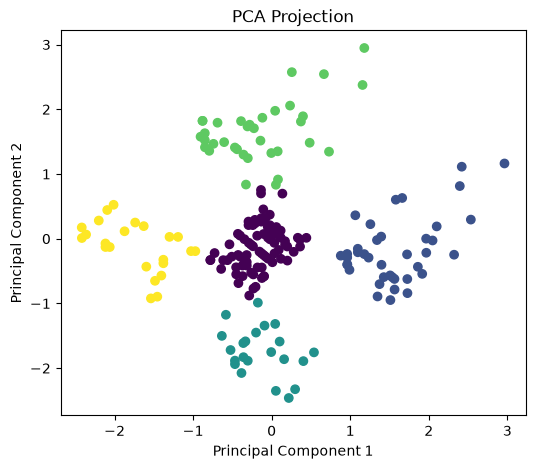

In [13]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)
plt.figure(figsize=(6,5))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=kmeans_labels,
    cmap='viridis'
)

plt.title("PCA Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()